<a href="https://colab.research.google.com/github/jioring4351/hongong-ML-study/blob/main/Chapter9/9_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSTM과 GRU셀

이 층들은 2절에서 공부했던 SimpleRNN보다 계싼이 훨씬 복잡하지만 성능이 뛰어나기 때문에 순환 신경망에 많이 채택된다.

일반적으로 기본 순환층은 긴 시퀀스를 학습하기 어려운데 시퀀스가 길수록 순환되는 은닉상태에 담긴 정보가 점차 희석되기 때문이다.

이를 위해 LSTM과 GRU셀이 발명되었다

## LSTM 셀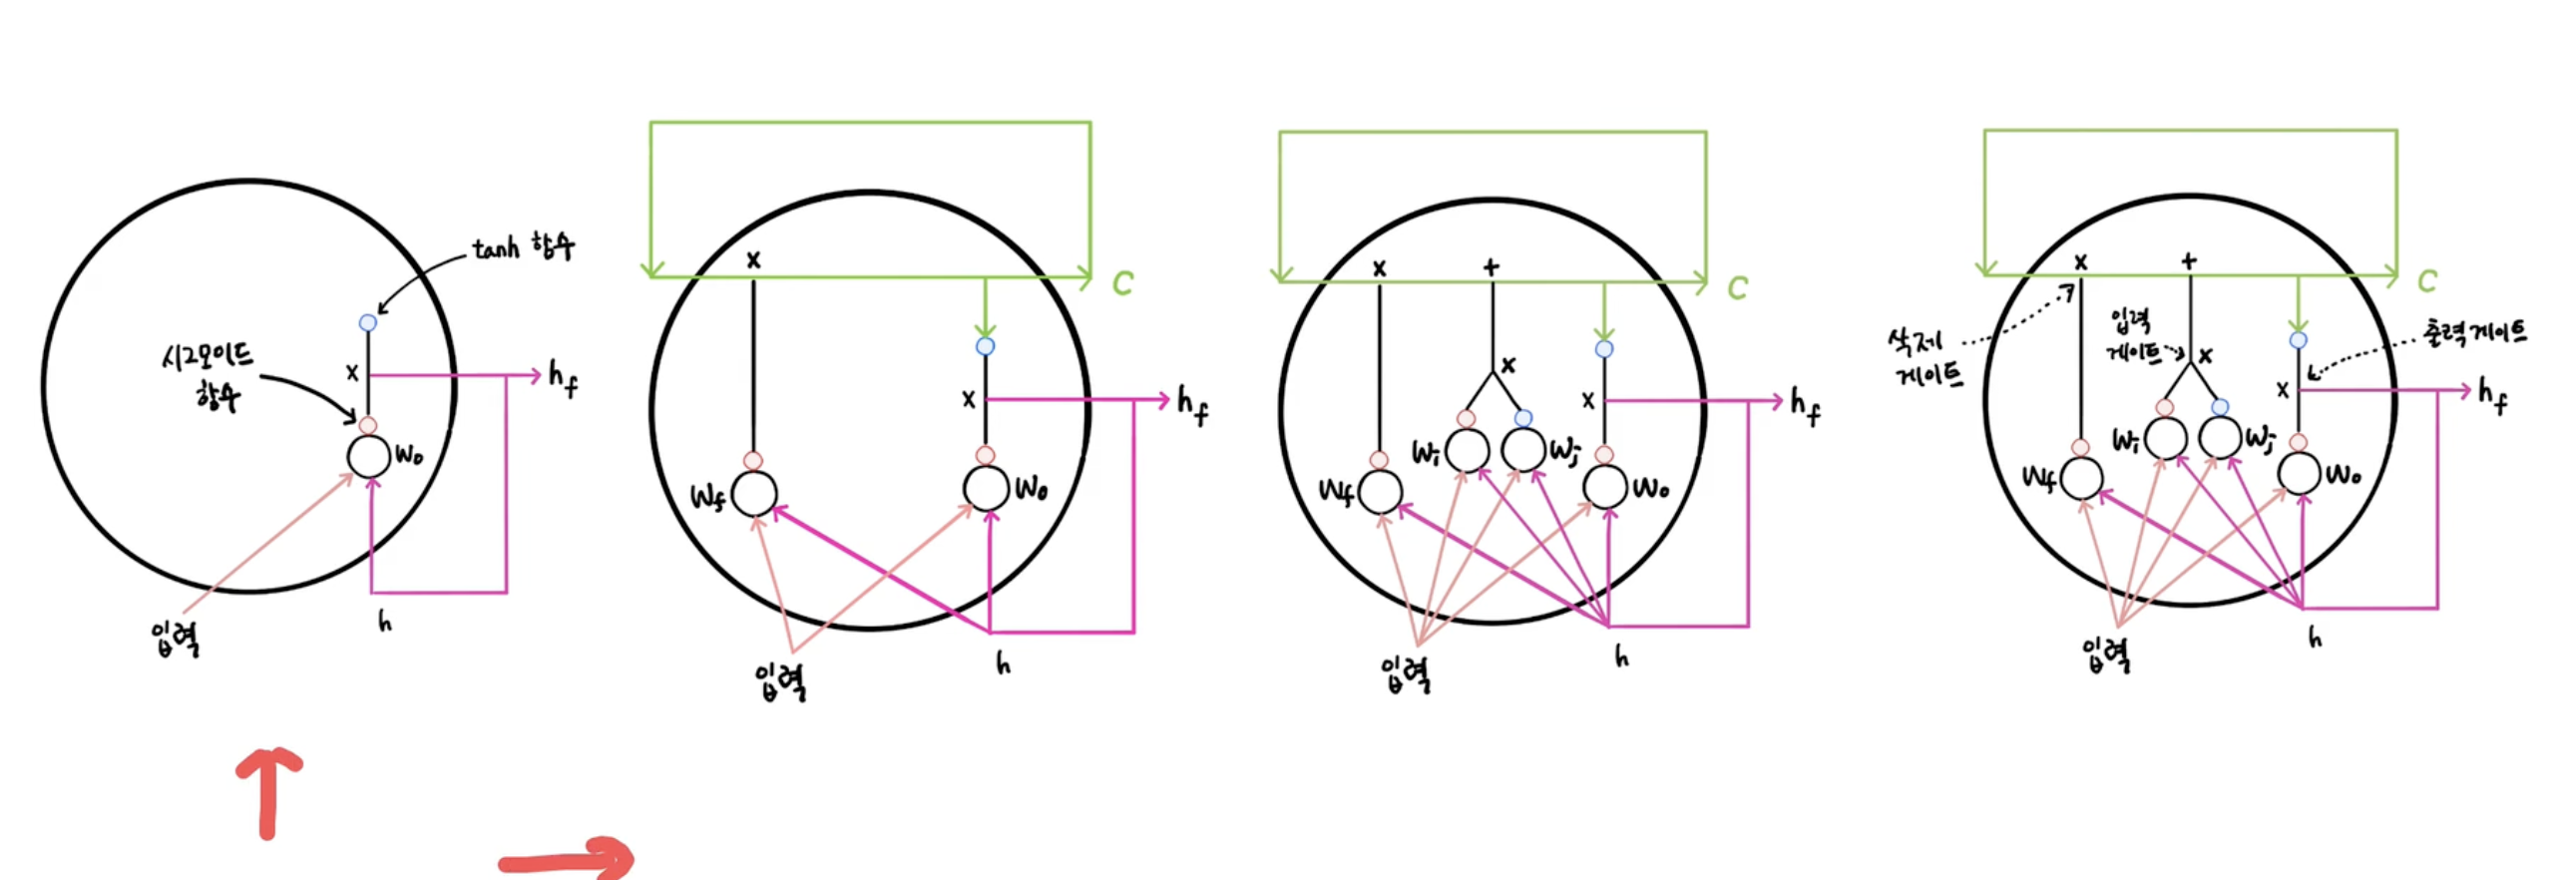

긴 텍스트가 주워졌을때 앞쪽에 나온 정보를 기억하지 못하는 문제를 해결하기 위해 단기기억을 늘려주는 셀이다.

In [1]:
from numpy.random import rand
#LSTM 신경망 훈련하기
#데이터 가져오기
from keras.datasets import imdb
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)  #자주사용하는 단어 500개

#검증세트 나누기
train_input, val_input, train_target, val_target = train_test_split(train_input, train_target, test_size = 0.2, random_state=42)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
#시퀀스 함수로 샘플의 길이를 100으로 맞추고 부족할때 패딩 추가
from keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [6]:
#LSTM셀을 사용한 순환층 만들기
import keras

model_lstm = keras.Sequential()
model_lstm.add(keras.layers.Input(shape=(100,)))
model_lstm.add(keras.layers.Embedding(500,16))
model_lstm.add(keras.layers.LSTM(8))
model_lstm.add(keras.layers.Dense(1, activation='sigmoid'))

In [7]:
#모델 구조 출력(SimpleRNN클래스에서 모델 파라미터 개수는 200개. LSTM셀에는 작은 셀이 4개 있으므로 정확히 4배가 늘어 800개)
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,809 (34.41 KB)

 Trainable params: 8,809 (34.41 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
#모델 훈련
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-lstm-model.keras', save_best_only=True)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

history = model_lstm.fit(train_seq, train_target, epochs=100, batch_size=64,
                         validation_data = (val_seq, val_target),
                         callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.6874 - loss: 0.5795 - val_accuracy: 0.7748 - val_loss: 0.4849
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.7802 - loss: 0.4745 - val_accuracy: 0.7778 - val_loss: 0.4709
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.7944 - loss: 0.4450 - val_accuracy: 0.7910 - val_loss: 0.4421
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.8001 - loss: 0.4315 - val_accuracy: 0.7986 - val_loss: 0.4464
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.8052 - loss: 0.4223 - val_accuracy: 0.8008 - val_loss: 0.4356
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.8050 - loss: 0.4219 - val_accuracy: 0.8024 - val_loss: 0.4405
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.8080 - loss: 0.4135 - val_accuracy: 0.7982 - val_loss: 0.4306
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.8112 - loss: 0

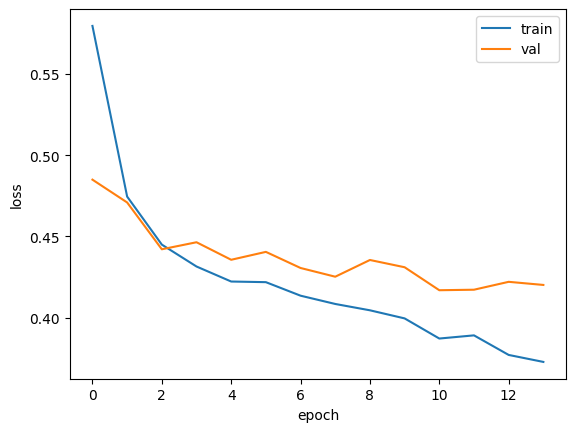

In [9]:
#훈련손실과 검증손실 그래프
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label ='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

## 순환층에 드롭아웃 적용하기
순환층은 자체적으로 드롭아웃 기능을 제공.



In [10]:
#드롭아웃을 사용하여 순환층 만들기
model_dropout = keras.Sequential()
model_dropout.add(keras.layers.Input(shape=(100,)))
model_dropout.add(keras.layers.Embedding(500,16))
model_dropout.add(keras.layers.LSTM(8, dropout=0.2))
model_dropout.add(keras.layers.Dense(1, activation='sigmoid'))

In [11]:
#모델 훈련
model_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-dropout-model.keras', save_best_only=True)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

history = model_dropout.fit(train_seq, train_target, epochs=100, batch_size=64,
                         validation_data = (val_seq, val_target),
                         callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.6768 - loss: 0.5953 - val_accuracy: 0.7632 - val_loss: 0.4999
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.7822 - loss: 0.4667 - val_accuracy: 0.7964 - val_loss: 0.4456
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.7998 - loss: 0.4342 - val_accuracy: 0.8042 - val_loss: 0.4324
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.8031 - loss: 0.4225 - val_accuracy: 0.8042 - val_loss: 0.4239
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.8057 - loss: 0.4161 - val_accuracy: 0.7902 - val_loss: 0.4439
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8086 - loss: 0.4115 - val_accuracy: 0.8036 - val_loss: 0.4277
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8122 - loss: 0.4082 - val_accuracy: 0.8044 - val_loss: 0.4304


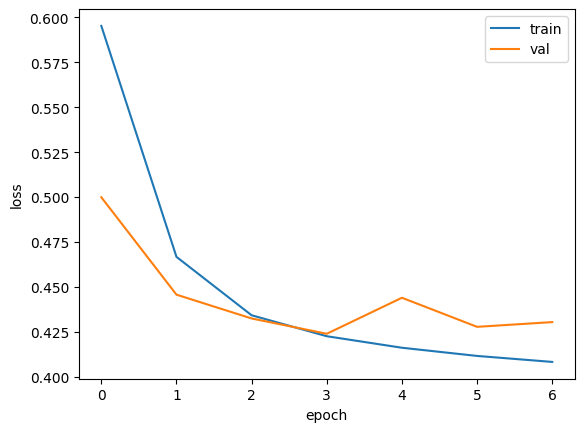

In [12]:
#훈련손실과 검증손실 그래프
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label ='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

## 두 개의 순환 층 연결하기
**순환층을 연결할 때는 주의할 점이 있는데 순환층의 은닉 상태는 샘플의 마지막 타임스텝에 대한 은닉 상태만 다음 층으로 전달한다. 순환층을 쌓게 되면 모든 순환층에 순차데이터가 필요하다. 따라서 오직 마지막 순환층만 마지막 타임스텝의 은닉 상태를 출력해야한다.**

In [14]:
model_2lstm = keras.Sequential()
model_2lstm.add(keras.layers.Input(shape=(100,)))
model_2lstm.add(keras.layers.Embedding(500,16))
model_2lstm.add(keras.layers.LSTM(8, dropout=0.2, return_sequences=True))
model_2lstm.add(keras.layers.LSTM(8, dropout=0.2))
model_2lstm.add(keras.layers.Dense(1, activation='sigmoid'))

#모델 구조 확인
model_2lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100, 8)         │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 8)              │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,353 (36.54 KB)

 Trainable params: 9,353 (36.54 KB)

 Non-trainable params: 0 (0.00 B)

첫 번째 LSTM 층이 모든 타임스텝(100개)의 은닉 상태를 출력하기 때문에 출력 크기가 (None, 100, 8)로 표시되었다.

이에 반해 두 번째 LSTM층의 출력 크기는 마지막 타임스텝의 은닉 상태만 출력하기 때문에 (None, 8)이다.

In [17]:
#모델 훈련
model_2lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-2lstm-model.keras', save_best_only=True)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

history = model_2lstm.fit(train_seq, train_target, epochs=100, batch_size=64,
                         validation_data = (val_seq, val_target),
                         callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 76ms/step - accuracy: 0.6689 - loss: 0.6026 - val_accuracy: 0.7614 - val_loss: 0.5120
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 75ms/step - accuracy: 0.7735 - loss: 0.4869 - val_accuracy: 0.7826 - val_loss: 0.4577
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 105ms/step - accuracy: 0.7929 - loss: 0.4498 - val_accuracy: 0.8006 - val_loss: 0.4400
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 114ms/step - accuracy: 0.7956 - loss: 0.4434 - val_accuracy: 0.7904 - val_loss: 0.4397
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 85ms/step - accuracy: 0.8010 - loss: 0.4309 - val_accuracy: 0.7968 - val_loss: 0.4369
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 117ms/step - accuracy: 0.8098 - loss: 0.4200 - val_accuracy: 0.8062 - val_loss: 0.4241
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.8127 - loss: 0.4107 - val_accuracy: 0.7918 - val_loss: 0.4399
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 74ms/step - accuracy: 0.8142 - loss

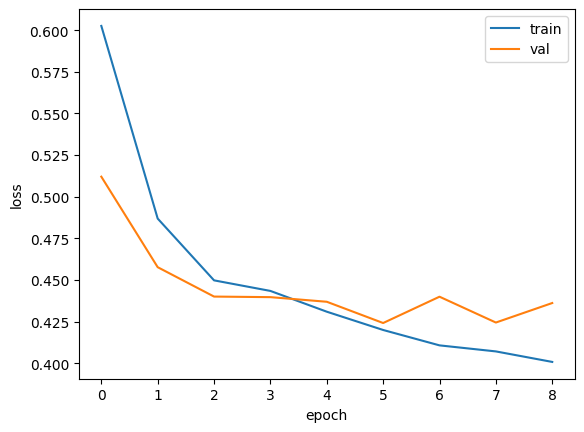

In [19]:
#모델은 잘 훈련되었지만 이 예에서는 순환층을 쌓아 큰 효과를 얻지는 못함. 하지만 일반적으로 순환층을 쌓으면 성능이 높아짐.

#훈련손실과 검증손실 그래프
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label ='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

## GRU 구조(셀)
LSTM 셀의 간소화 버전이라 볼 수 있다.

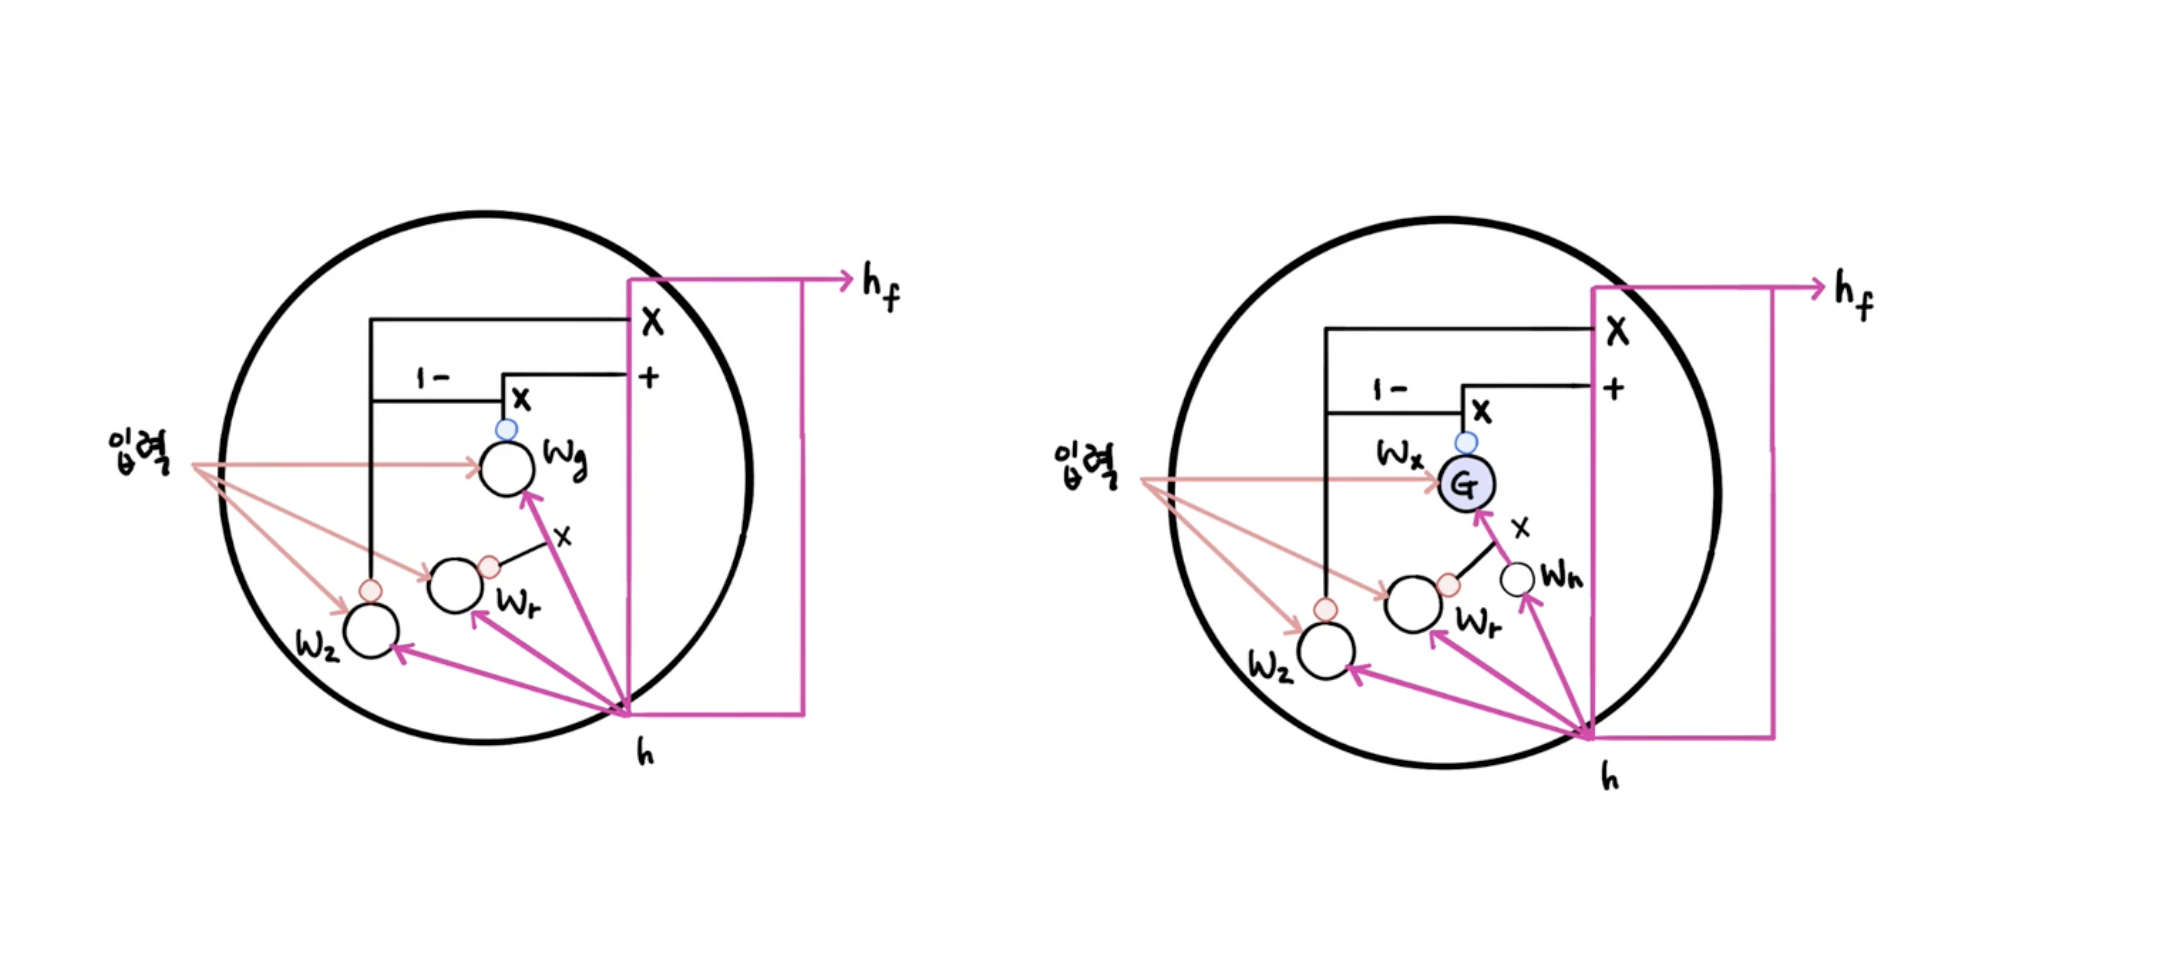

GRU 셀은 LSTM보다 가중치가 적기 때문에 계산량이 적지만 LSTM 못지 않은 좋은 성능을 내는 것으로 알려져 있다.

In [18]:
#GRU 신경만 훈련하기
#GRU셀을 이용한 순환층 만들기
model_gru = keras.Sequential()
model_gru.add(keras.layers.Input(shape=(100,)))
model_gru.add(keras.layers.Embedding(500,16))
model_gru.add(keras.layers.GRU(8, dropout=0.2))
model_gru.add(keras.layers.Dense(1, activation='sigmoid'))

In [20]:
#모델 구조 확인
model_gru.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 8)              │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,633 (33.72 KB)

 Trainable params: 8,633 (33.72 KB)

 Non-trainable params: 0 (0.00 B)

GRU 셀에는 3개의 작은 셀이 존재. 작은 셀에는 입력과 은닉 상태에 곱하는 가중치와 절편 존재

입력에 곱하는 가중치는 16 * 8 = 128

은닉상태에 곱하는 가중치는 8 * 8 = 64

뉴런마다 절편 하나씩 8개이므로 총 200이다.

이런 작은 셀이 3개이므로 3배해서 600개의 모델 파라미터가 나와야하는데 624개인 이유는 은닉 상태가 먼저 가중치와 곱해진 다음 가운데 셀의 출력과 곱해지기 때문이다.

작은 셀마다 하나씩 절편이 추가되어 8 * 3 = 24개가 추가된다

In [21]:
#모델 훈련
model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-gru-model.keras', save_best_only=True)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

history = model_gru.fit(train_seq, train_target, epochs=100, batch_size=64,
                         validation_data = (val_seq, val_target),
                         callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.6399 - loss: 0.6239 - val_accuracy: 0.7416 - val_loss: 0.5211
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 89ms/step - accuracy: 0.7639 - loss: 0.4987 - val_accuracy: 0.7764 - val_loss: 0.4741
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 115ms/step - accuracy: 0.7832 - loss: 0.4682 - val_accuracy: 0.7834 - val_loss: 0.4597
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 102ms/step - accuracy: 0.7978 - loss: 0.4454 - val_accuracy: 0.7932 - val_loss: 0.4468
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.8037 - loss: 0.4337 - val_accuracy: 0.7744 - val_loss: 0.4691
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.8049 - loss: 0.4274 - val_accuracy: 0.8000 - val_loss: 0.4318
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.8067 - loss: 0.4242 - val_accuracy: 0.8006 - val_loss: 0.4281
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.8124 - loss:

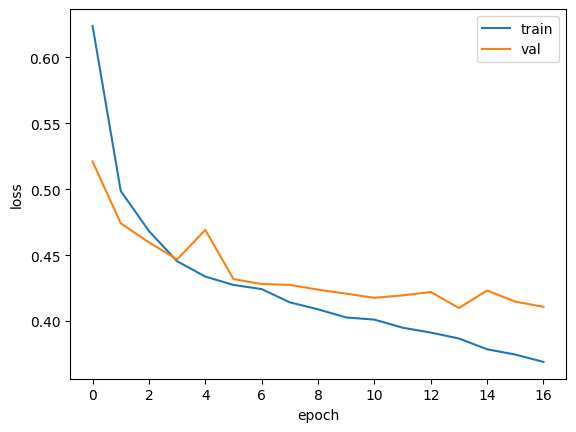

In [22]:
#훈련손실과 검증손실 그래프
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label ='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [23]:
#GRU 모델을 다시 로드하여 테스트 세트에 대한 성능 확인
test_seq = pad_sequences(test_input, maxlen = 100)
best_model = keras.models.load_model('best-gru-model.keras')
best_model.evaluate(test_seq, test_target)

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8176 - loss: 0.4025


[0.4025316834449768, 0.8175600171089172]